----

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import math as mt
from math import factorial
from scipy import stats as st

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')


## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Toda la información es consistente en cuanto al tipo de dato y nombre de columna, posiblemente sea más conveniente trabajar mb_per_month_included en Gigas en lugar de megas, pero lo trabajaré en función de las columnas de las otras tablas disponibles.

## Corregir datos

## Enriquecer los datos

## Usuarios/as

In [5]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [6]:
# Imprime una muestra de datos para usuarios
users.head(10)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaN
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaN
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaN
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaN


Los tipos de datos y la información es consistente con la excepción de reg_date y churn_date que se registran con tipo "object" y deben ser registrados con el tipo adecuado, se observan 34 fechas de 500 en churn_date lo que implica que los restantes son usuarios activos, se establecerá una fecha ficticia para saber que son usuarios activos manteniendo uniformidad  en el tipo de datos de la columna. 

### Corregir los datos

In [7]:
users['reg_date']   = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

users['churn_date'] = users['churn_date'].fillna(np.datetime64('2100-01-01'))
#usando la fecha "2100-01-01" para denotar que el cliente sigue activo

users.info()
print()
users.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  500 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,2100-01-01
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,2100-01-01
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,2100-01-01
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,2100-01-01
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,2100-01-01
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,2100-01-01
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,2100-01-01
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,2100-01-01
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,2100-01-01


### Enriquecer los datos

## Llamadas

In [8]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [9]:
# Imprime una muestra de datos para las llamadas

calls.head(10)

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
5,1000_388,1000,2018-12-31,2.20
6,1000_510,1000,2018-12-27,5.75
7,1000_521,1000,2018-12-28,14.18
8,1000_530,1000,2018-12-28,5.77
9,1000_544,1000,2018-12-26,4.40


Todo consistente, el tipo de objeto para call_date se debe convertir a fecha únicamente.

### Corregir los datos

In [10]:
calls['call_date'] = pd.to_datetime(calls['call_date'], errors='coerce')

calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


### Enriquecer los datos

In [11]:
#Se realiza la corrección redondeando hacia arriba los minutos de 'duration'
calls['duration'] = np.ceil(calls['duration'])
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,9.0
1,1000_145,1000,2018-12-27,14.0
2,1000_247,1000,2018-12-27,15.0
3,1000_309,1000,2018-12-28,6.0
4,1000_380,1000,2018-12-30,5.0


## Mensajes

In [12]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [13]:
# Imprime una muestra de datos para los mensajes

print(messages.head(10))

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
5  1000_346     1000   2018-12-29
6  1000_386     1000   2018-12-30
7  1000_413     1000   2018-12-31
8  1000_502     1000   2018-12-27
9  1000_525     1000   2018-12-28


Al igual que en los anteriores, se debe modificar unicamente el tipo de objeto para message_date.

### Corregir los datos

In [14]:
messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')

messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriquecer los datos

## Internet

In [15]:
# Imprime la información general/resumida sobre el DataFrame de internet

internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [16]:
# Imprime una muestra de datos para el tráfico de internet

internet.head(10)

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
5,1001_0,1001,2018-08-24,284.68
6,1001_3,1001,2018-12-09,656.04
7,1001_4,1001,2018-11-04,16.97
8,1001_10,1001,2018-11-27,135.18
9,1001_15,1001,2018-12-13,761.92


Todo conforme, únicamente se debe corregir el tipo de session_date, los mg_used coinciden en la unidad de medida con mg_per_month_included así que no es necesario realizar la conversión para cualquier comparación necesaria.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [17]:
internet['session_date'] = pd.to_datetime(internet['session_date'], errors='coerce')
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriquecer los datos

## Estudiar las condiciones de las tarifas

In [18]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

print(plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Agregar datos por usuario

In [19]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
# Columna para mes y para año
calls['year'] = calls['call_date'].dt.year
calls['month'] = calls['call_date'].dt.month
# Agrupando cantidad de llamads por usuario al mes
calls.groupby(['user_id', 'year', 'month']).agg(calls_count=('id', 'count')).reset_index()

,user_id,year,month,calls_count
0,1000,2018,12,16
1,1001,2018,8,27
2,1001,2018,9,49
3,1001,2018,10,65
4,1001,2018,11,64
...,...,...,...,...
2253,1498,2018,12,39
2254,1499,2018,9,41
2255,1499,2018,10,53
2256,1499,2018,11,45


In [20]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
# Agrupando minutos totales por usuario al mes
calls.groupby(['user_id', 'year', 'month']).agg(total_minutes=('duration', 'sum')).reset_index()


,user_id,year,month,total_minutes
0,1000,2018,12,124.0
1,1001,2018,8,182.0
2,1001,2018,9,315.0
3,1001,2018,10,393.0
4,1001,2018,11,426.0
...,...,...,...,...
2253,1498,2018,12,339.0
2254,1499,2018,9,346.0
2255,1499,2018,10,385.0
2256,1499,2018,11,308.0


In [21]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
# Columna para mes y para año
messages['year'] = messages['message_date'].dt.year
messages['month'] = messages['message_date'].dt.month
# Agrupando mensajes por usuario al mes
messages.groupby(['user_id', 'year', 'month']).agg(msg_count=('id', 'count')).reset_index()


,user_id,year,month,msg_count
0,1000,2018,12,11
1,1001,2018,8,30
2,1001,2018,9,44
3,1001,2018,10,53
4,1001,2018,11,36
...,...,...,...,...
1801,1496,2018,9,21
1802,1496,2018,10,18
1803,1496,2018,11,13
1804,1496,2018,12,11


In [22]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
# Columna para mes y para año
internet['year'] = internet['session_date'].dt.year
internet['month'] = internet['session_date'].dt.month
# Agrupando la cantidad de megas usadas por usuario al mes
internet.groupby(['user_id', 'year', 'month']).agg(total_mb_used=('mb_used', 'sum')
).reset_index()


,user_id,year,month,total_mb_used
0,1000,2018,12,1901.47
1,1001,2018,8,6919.15
2,1001,2018,9,13314.82
3,1001,2018,10,22330.49
4,1001,2018,11,18504.30
...,...,...,...,...
2272,1498,2018,12,23137.69
2273,1499,2018,9,12984.76
2274,1499,2018,10,19492.43
2275,1499,2018,11,16813.83


In [23]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
# Cantidad de llamadas y minutos por usuario al mes
calls['year'] = calls['call_date'].dt.year
calls['month'] = calls['call_date'].dt.month

calls_grouped = calls.groupby(['user_id', 'year', 'month']).agg(calls_count=('id', 'count'), total_minutes=('duration', 'sum')).reset_index()

# Cantidad de mensajes por usuario al mes
messages['year'] = messages['message_date'].dt.year
messages['month'] = messages['message_date'].dt.month

messages_grouped = messages.groupby(['user_id', 'year', 'month']).agg(msg_count=('id', 'count')).reset_index()

# Cantidad de megas de internet consumidos por usuario al mes
internet['year'] = internet['session_date'].dt.year
internet['month'] = internet['session_date'].dt.month

internet_grouped = internet.groupby(['user_id', 'year', 'month']).agg(total_mb_used=('mb_used', 'sum')).reset_index()

# Outer merge para evitar perdida de datos
user_stats = calls_grouped.merge(messages_grouped, on=['user_id','year','month'], how='outer')
user_stats = user_stats.merge(internet_grouped, on=['user_id','year','month'], how='outer')

# Sustituir NaN con 0 para efectos de calculos
user_stats = user_stats.fillna(0)

print(user_stats.head(10))

   user_id  year  month  calls_count  total_minutes  msg_count  total_mb_used
0     1000  2018     12         16.0          124.0       11.0        1901.47
1     1001  2018      8         27.0          182.0       30.0        6919.15
2     1001  2018      9         49.0          315.0       44.0       13314.82
3     1001  2018     10         65.0          393.0       53.0       22330.49
4     1001  2018     11         64.0          426.0       36.0       18504.30
5     1001  2018     12         56.0          412.0       44.0       19369.18
6     1002  2018     10         11.0           59.0       15.0        6552.01
7     1002  2018     11         55.0          386.0       32.0       19345.08
8     1002  2018     12         47.0          384.0       41.0       14396.24
9     1003  2018     12        149.0         1104.0       50.0       27044.14


In [24]:
# Añade la información de la tarifa
# Debido a que 'plans' no tiene columnas en común para merge, empezamos por users

users_plans = users[['user_id', 'plan']]

# Merge con user_stats, a la izquierda para que se haga en función de la tabla general
user_stats = user_stats.merge(users_plans, on='user_id', how='left')


# Merge de la tabla general con plans para agregar info de tarifas
user_stats = user_stats.merge(plans, left_on='plan', right_on='plan_name', how='left')

print(user_stats.head(10))

   user_id  year  month  calls_count  total_minutes  msg_count  total_mb_used  \
0     1000  2018     12         16.0          124.0       11.0        1901.47   
1     1001  2018      8         27.0          182.0       30.0        6919.15   
2     1001  2018      9         49.0          315.0       44.0       13314.82   
3     1001  2018     10         65.0          393.0       53.0       22330.49   
4     1001  2018     11         64.0          426.0       36.0       18504.30   
5     1001  2018     12         56.0          412.0       44.0       19369.18   
6     1002  2018     10         11.0           59.0       15.0        6552.01   
7     1002  2018     11         55.0          386.0       32.0       19345.08   
8     1002  2018     12         47.0          384.0       41.0       14396.24   
9     1003  2018     12        149.0         1104.0       50.0       27044.14   

       plan  messages_included  mb_per_month_included  minutes_included  \
0  ultimate               1000   

In [25]:
# Calcula el ingreso mensual para cada usuario
# Excedente de minutos - clip(lower=0) para que los negativos sean iguales a 0
user_stats['extra_minutes'] = (user_stats['total_minutes'] - user_stats['minutes_included']).clip(lower=0)

# Excedente de SMS - clip(lower=0) para que los negativos sean iguales a 0
user_stats['extra_sms'] = (user_stats['msg_count'] - user_stats['messages_included']).clip(lower=0)

# Excedente de datos: np.ceil para aprox MB usados a GB redondeando hacia arriba
# Factor de conversión: 1024 MB a 1 GB
extra_mb = (user_stats['total_mb_used'] - user_stats['mb_per_month_included']).clip(lower=0)
user_stats['extra_gb'] = np.ceil(extra_mb / 1024)

# Ingresos adicionales
user_stats['cost_xtra_minutes'] = user_stats['extra_minutes'] * user_stats['usd_per_minute']
user_stats['cost_xtra_sms'] = user_stats['extra_sms'] * user_stats['usd_per_message']
user_stats['cost_xtra_gb'] = user_stats['extra_gb'] * user_stats['usd_per_gb']

# Ingreso total
user_stats['total_revenue'] = (user_stats['usd_monthly_pay'] + user_stats['cost_xtra_minutes'] + user_stats['cost_xtra_sms'] + user_stats['cost_xtra_gb'])

print(user_stats.head(5))

   user_id  year  month  calls_count  total_minutes  msg_count  total_mb_used  \
0     1000  2018     12         16.0          124.0       11.0        1901.47   
1     1001  2018      8         27.0          182.0       30.0        6919.15   
2     1001  2018      9         49.0          315.0       44.0       13314.82   
3     1001  2018     10         65.0          393.0       53.0       22330.49   
4     1001  2018     11         64.0          426.0       36.0       18504.30   

       plan  messages_included  mb_per_month_included  ...  usd_per_message  \
0  ultimate               1000                  30720  ...             0.01   
1      surf                 50                  15360  ...             0.03   
2      surf                 50                  15360  ...             0.03   
3      surf                 50                  15360  ...             0.03   
4      surf                 50                  15360  ...             0.03   

   usd_per_minute  plan_name  extra_mi

## Estudia el comportamiento de usuario

### Llamadas

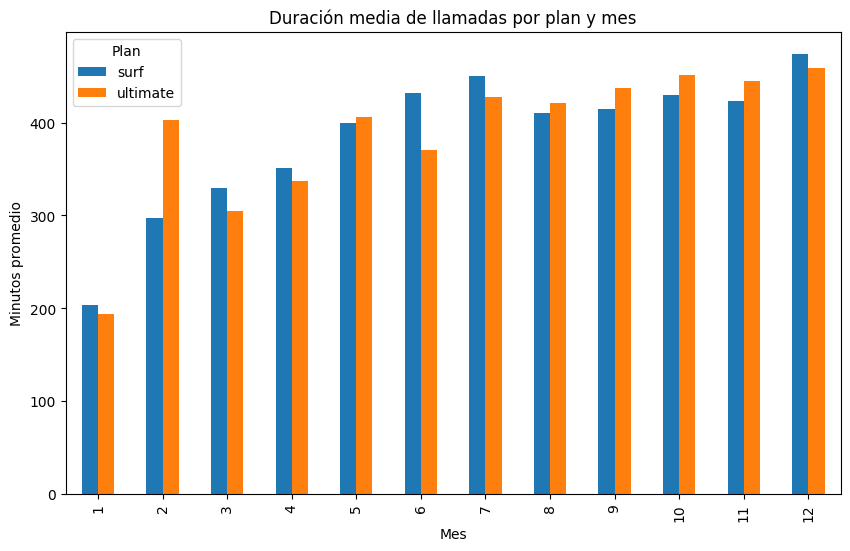

In [26]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
# Agrupando por plan y mes en función de la duración promedio de llamadas.
call_dur_avg =  user_stats.groupby(['plan', 'month'])['total_minutes'].mean().reset_index()
# Gráfico de barras
pivot = call_dur_avg.pivot(index='month', columns='plan', values='total_minutes')
pivot.plot(figsize=[10,6], kind='bar', title="Duración media de llamadas por plan y mes")
plt.xlabel("Mes")
plt.ylabel("Minutos promedio")
plt.legend(title="Plan")
plt.show()


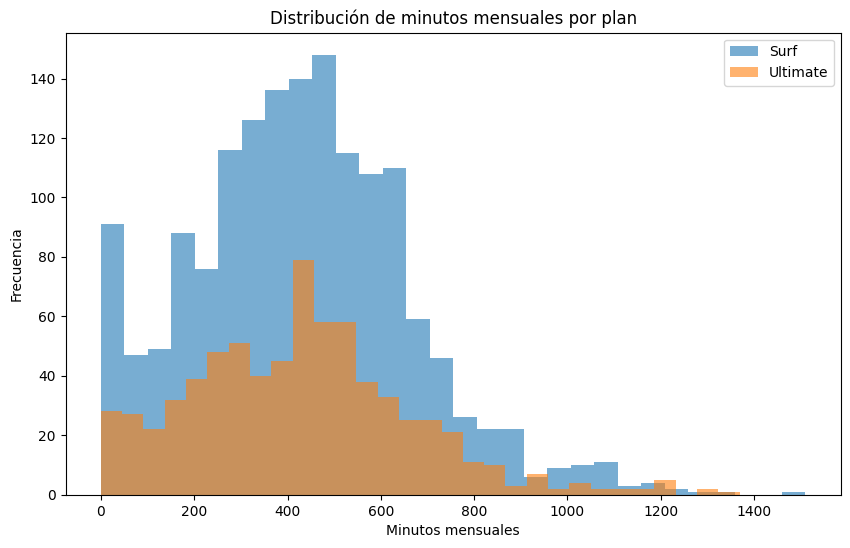

In [27]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

user_stats[user_stats['plan']=="surf"]['total_minutes'].plot(
    kind='hist', bins=30, alpha=0.6, figsize=[10,6], label="Surf"
)
user_stats[user_stats['plan']=="ultimate"]['total_minutes'].plot(
    kind='hist', bins=30, alpha=0.6, figsize=[10,6], label="Ultimate"
)
plt.title("Distribución de minutos mensuales por plan")
plt.xlabel("Minutos mensuales")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


In [28]:
# Calcula la media y la varianza de la duración mensual de llamadas.

call_mean_var = user_stats.groupby('plan')['total_minutes'].agg(
    mean='mean',
    variance='var',
    std_dev='std'
).reset_index()

print(call_mean_var)

       plan        mean      variance     std_dev
0      surf  428.749523  54968.279461  234.453150
1  ultimate  430.450000  57844.464812  240.508762


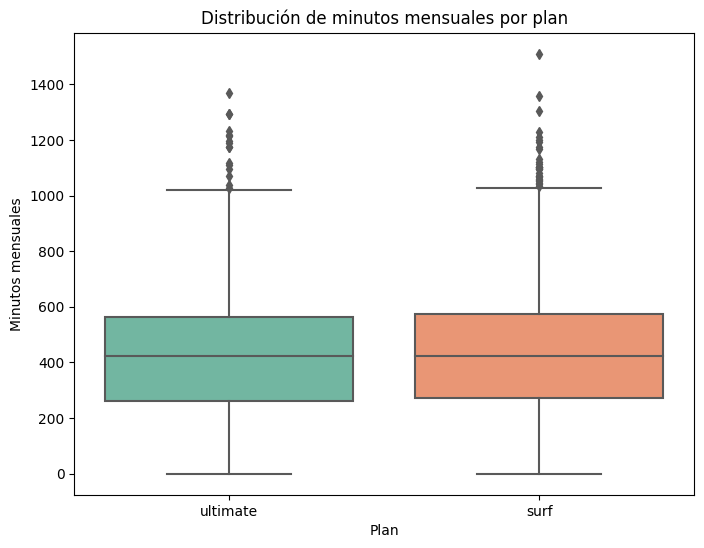

In [29]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(8,6))
sns.boxplot(data=user_stats, x="plan", y="total_minutes", palette="Set2")
plt.title("Distribución de minutos mensuales por plan")
plt.xlabel("Plan")
plt.ylabel("Minutos mensuales")
plt.show()


A partir del segundo semestre se incrementan los minutos en llamadas para ambos planes, no se ve diferencia sustancial en el uso de los minutos por plan (en promedio 2 minutos más al mes para el plan más caro).

### Mensajes

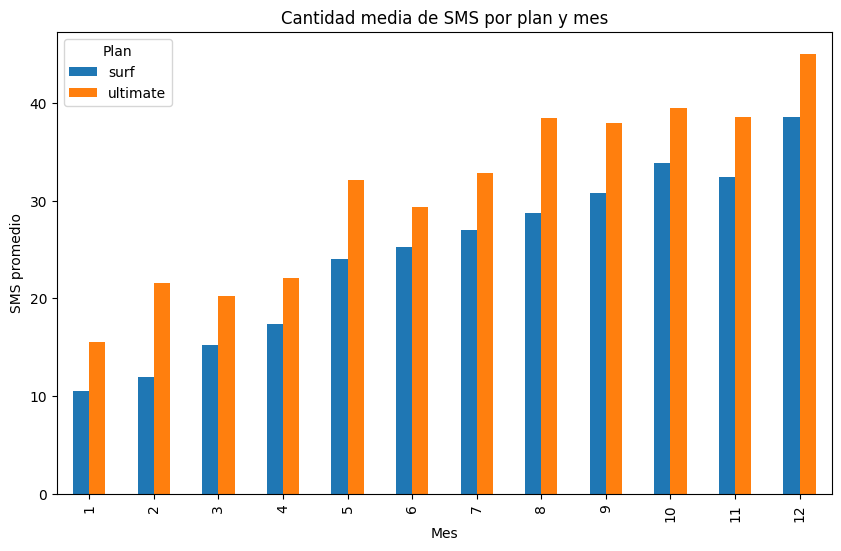

In [30]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

sms_avg = user_stats.groupby(['plan', 'month'])['msg_count'].mean().reset_index()
pivot_sms = sms_avg.pivot(index='month', columns='plan', values='msg_count')

pivot_sms.plot(
    figsize=[10,6], 
    kind='bar',
    title="Cantidad media de SMS por plan y mes"
)
plt.xlabel("Mes")
plt.ylabel("SMS promedio")
plt.legend(title="Plan")
plt.show()

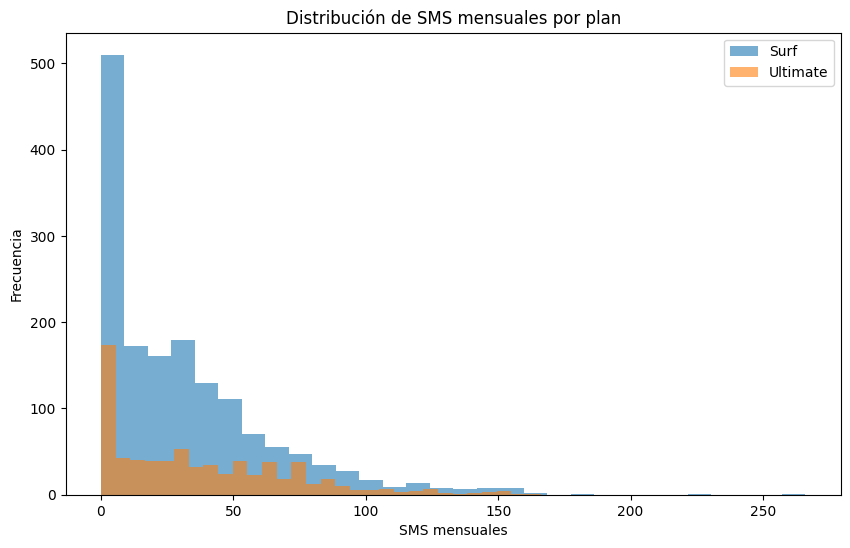

In [31]:
user_stats[user_stats['plan']=="surf"]['msg_count'].plot(
    kind='hist', bins=30, alpha=0.6, figsize=[10,6], label="Surf"
)
user_stats[user_stats['plan']=="ultimate"]['msg_count'].plot(
    kind='hist', bins=30, alpha=0.6, figsize=[10,6], label="Ultimate"
)
plt.title("Distribución de SMS mensuales por plan")
plt.xlabel("SMS mensuales")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

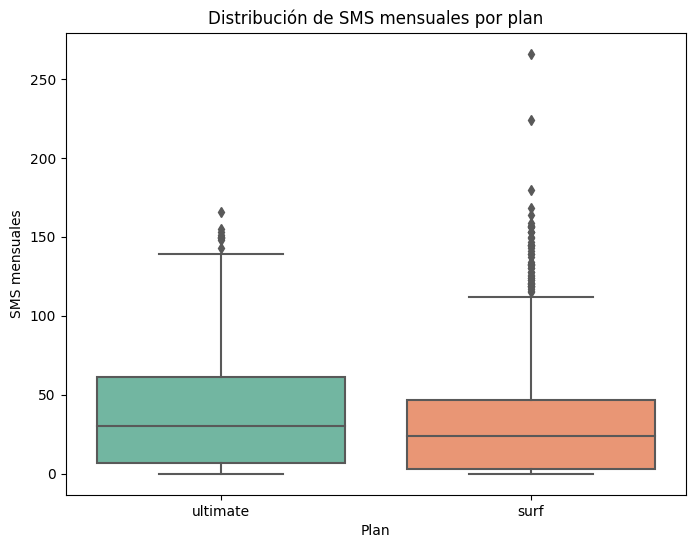

In [32]:
plt.figure(figsize=(8,6))
sns.boxplot(data=user_stats, x="plan", y="msg_count", palette="Set2")
plt.title("Distribución de SMS mensuales por plan")
plt.xlabel("Plan")
plt.ylabel("SMS mensuales")
plt.show()

Se da un incremento en el envío de SMS a partir de agosto alcanzando su punto más alto en diciembre y decae al punto más bajo en enero, en promedio se consumen más mensajes de texto en el plan más caro.

### Internet

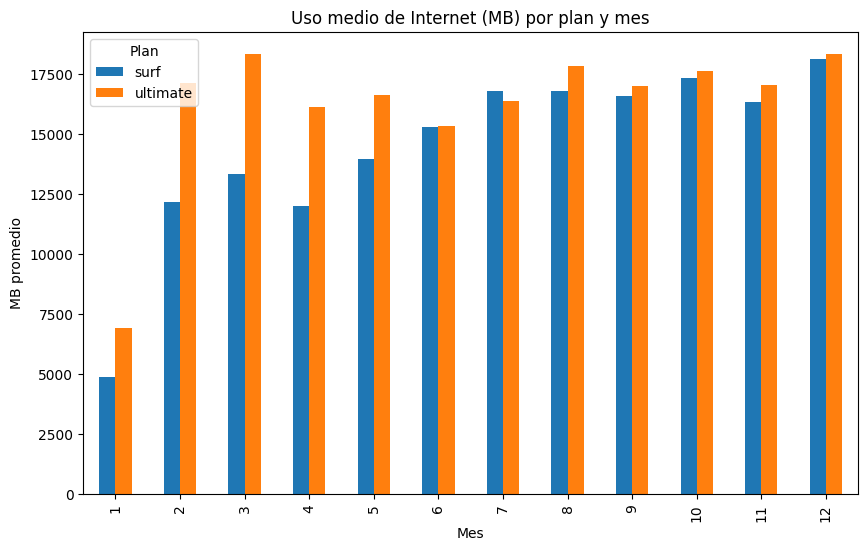

In [33]:
internet_avg = user_stats.groupby(['plan', 'month'])['total_mb_used'].mean().reset_index()
pivot_internet = internet_avg.pivot(index='month', columns='plan', values='total_mb_used')

pivot_internet.plot(
    figsize=[10,6], 
    kind='bar',
    title="Uso medio de Internet (MB) por plan y mes"
)
plt.xlabel("Mes")
plt.ylabel("MB promedio")
plt.legend(title="Plan")
plt.show()

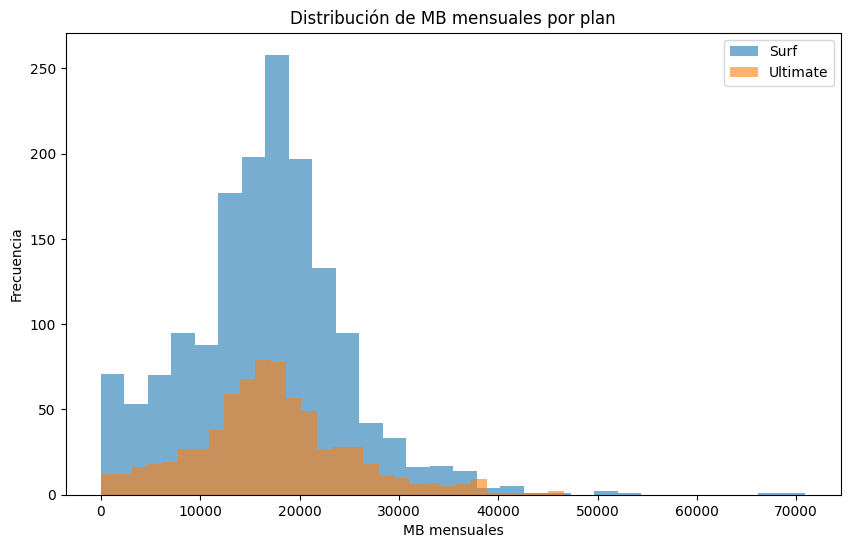

In [34]:
user_stats[user_stats['plan']=="surf"]['total_mb_used'].plot(
    kind='hist', bins=30, alpha=0.6, figsize=[10,6], label="Surf"
)
user_stats[user_stats['plan']=="ultimate"]['total_mb_used'].plot(
    kind='hist', bins=30, alpha=0.6, figsize=[10,6], label="Ultimate"
)
plt.title("Distribución de MB mensuales por plan")
plt.xlabel("MB mensuales")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

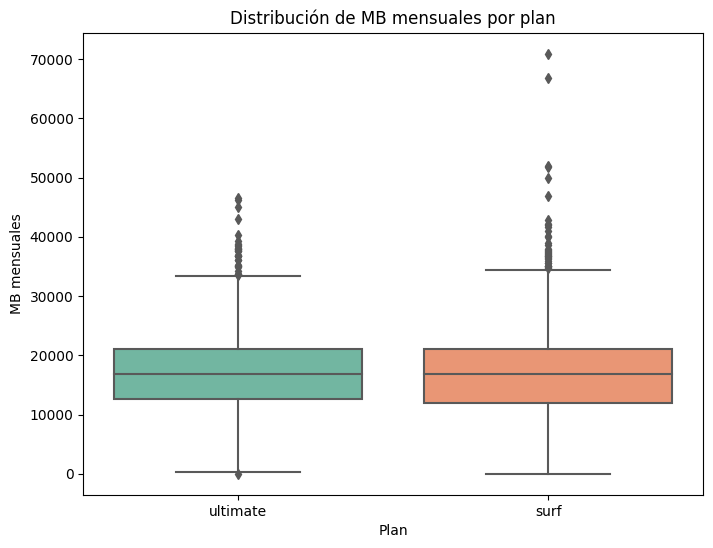

In [35]:
plt.figure(figsize=(8,6))
sns.boxplot(data=user_stats, x="plan", y="total_mb_used", palette="Set2")
plt.title("Distribución de MB mensuales por plan")
plt.xlabel("Plan")
plt.ylabel("MB mensuales")
plt.show()

El primer semestre, el consumo de datos es mayor en el plan más caro pero se nivelan en el segundo semestre, el mes de menor consumo de datos es enero y el más alto diciembre, correspondiente con los datos generados en llamadas y SMS, pero se registra una diferencia significativa en el primer trimestre debido al alto consumo de datos para el plan más caro en este periodo con contraste al más barato.

## Ingreso

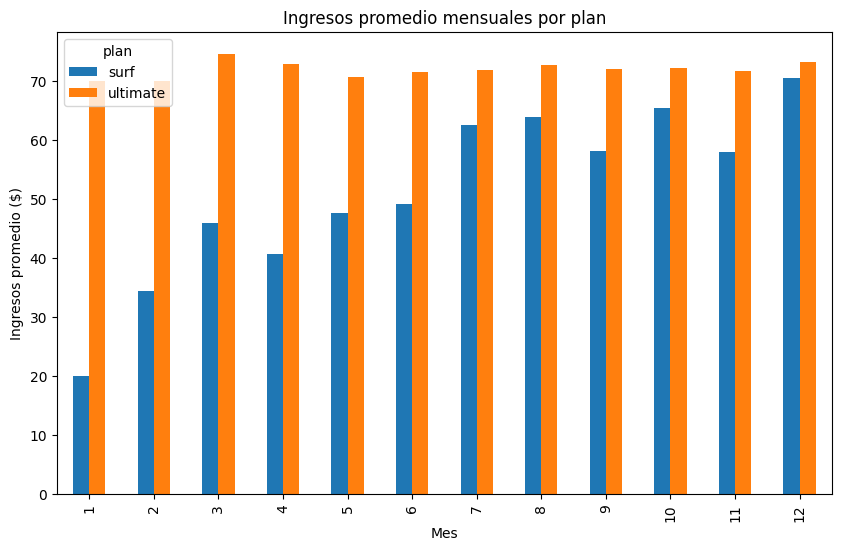

In [36]:
# Calcular el ingreso promedio por plan y mes
revenue_by_month = user_stats.groupby(['plan','month'])['total_revenue'].mean().reset_index()

# Gráfico de barras con pandas
revenue_by_month.pivot(index='month', columns='plan', values='total_revenue').plot(
    kind='bar', figsize=[10,6], title="Ingresos promedio mensuales por plan"
)
plt.xlabel("Mes")
plt.ylabel("Ingresos promedio ($)")
plt.show()

In [37]:
revenue_stats = user_stats.groupby('plan')['total_revenue'].agg(
    mean='mean',
    variance='var',
    std_dev='std'
).reset_index()

print(revenue_stats)

       plan       mean     variance    std_dev
0      surf  60.706408  3067.835152  55.388042
1  ultimate  72.313889   129.848486  11.395108


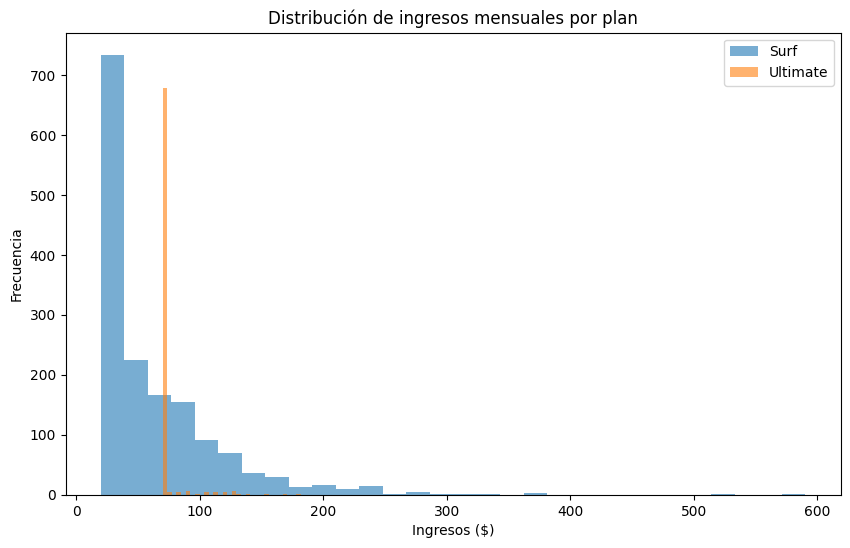

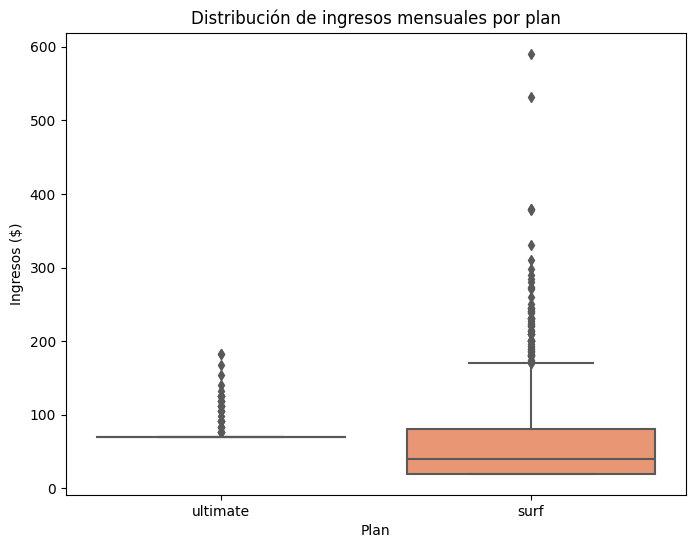

In [38]:
# Histograma de ingresos por plan
user_stats[user_stats['plan']=="surf"]['total_revenue'].plot(
    kind='hist', bins=30, alpha=0.6, figsize=[10,6], label="Surf"
)
user_stats[user_stats['plan']=="ultimate"]['total_revenue'].plot(
    kind='hist', bins=30, alpha=0.6, figsize=[10,6], label="Ultimate"
)
plt.title("Distribución de ingresos mensuales por plan")
plt.xlabel("Ingresos ($)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

print()

# Boxplot de ingresos
plt.figure(figsize=(8,6))
sns.boxplot(data=user_stats, x="plan", y="total_revenue", palette="Set2")
plt.title("Distribución de ingresos mensuales por plan")
plt.xlabel("Plan")
plt.ylabel("Ingresos ($)")
plt.show()


Los ingresos mensuales difieren en su comportamiento por mes evaluado, mientras que el plan más caro (ultimate) genera mayores ingresos en promedio con respecto al más barato (surf), tambien se muestra estable a lo largo del año, mientras que el plan "surf" tiene una tendencia ascendente desde enero hasta diciembre.

## Prueba las hipótesis estadísticas

Hipótesis nula (H₀):
El ingreso promedio de los usuarios de Ultimate es igual al de los usuarios de Surf.

Hipótesis alternativa (H₁):
El ingreso promedio de los usuarios de Ultimate es diferente al de los usuarios de Surf.

In [39]:
# Prueba las hipótesis

alpha = 0.05
income_ultimate = user_stats[user_stats['plan'] == 'ultimate']['total_revenue']
income_surf = user_stats[user_stats['plan'] == 'surf']['total_revenue']
t_test = st.stats.ttest_ind(income_ultimate, income_surf, equal_var = False)
print("Results:", t_test.pvalue )
if t_test.pvalue < 0.05:
    print("Rechazamos H0: los ingresos promedio son diferentes")
else:
    print("No rechazamos H0: no hay evidencia de diferencia en los ingresos promedio")



Results: 3.1703905481135734e-15
Rechazamos H0: los ingresos promedio son diferentes


/tmp/ipykernel_90/1857216099.py:6: DeprecationWarning: Please use `ttest_ind` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  t_test = st.stats.ttest_ind(income_ultimate, income_surf, equal_var = False)


Hipótesis nula (H₀):
El ingreso promedio de los usuarios de NY-NJ es igual al de los usuarios de otras regiones.

Hipótesis alternativa (H₁):
El ingreso promedio de los usuarios de NY-NJ es diferente al de los usuarios de otras regiones.

In [40]:
# Merge de la info general con users para relacionar con la ciudad
users_city = users[['user_id', 'city']]

# Merge con user_stats, a la izquierda para que se haga en función de la tabla general
user_stats = user_stats.merge(users_city, on='user_id', how='left')

# Filtrar en función de NY y de NJ
msk = user_stats['city'].str.contains("New York|New Jersey", case=False, na=False)
user_stats_nynj = user_stats[msk]
user_stats_other = user_stats[~msk]

# Prueba las hipótesis

alpha = 0.05
income_NYNJ = user_stats_nynj['total_revenue']
income_other = user_stats_other['total_revenue']

t_test = st.stats.ttest_ind(income_NYNJ, income_other, equal_var = False)
print("Results:", t_test.pvalue )
if t_test.pvalue < 0.05:
    print("Rechazamos H0: los ingresos promedio son diferentes")
else:
    print("No rechazamos H0: no hay evidencia de diferencia en los ingresos promedio")



Results: 0.0335256158853001
Rechazamos H0: los ingresos promedio son diferentes


/tmp/ipykernel_90/2084880222.py:18: DeprecationWarning: Please use `ttest_ind` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  t_test = st.stats.ttest_ind(income_NYNJ, income_other, equal_var = False)


## Conclusión general
A lo largo del año, se observan patrones de consumo similares entre los planes Surf y Ultimate, aunque con algunas diferencias clave:

Llamadas: A partir del segundo semestre, el consumo de minutos aumenta para ambos planes, pero la diferencia promedio entre ellos es mínima (aproximadamente 2 minutos más por mes para el plan Ultimate).

SMS: El envío de mensajes de texto incrementa desde agosto, alcanza su punto máximo en diciembre y disminuye a su nivel más bajo en enero. En promedio, los usuarios del plan Ultimate consumen más SMS que los del plan Surf.

Datos: Durante el primer semestre, el consumo de datos es mayor en el plan Ultimate, mientras que en el segundo semestre se nivela entre ambos planes. Enero representa el mes de menor consumo y diciembre el más alto, reflejando la misma tendencia que en llamadas y SMS. Sin embargo, existe una diferencia significativa en el primer trimestre debido al alto consumo de datos de los usuarios del plan Ultimate.

Ingresos: El plan Ultimate genera mayores ingresos promedio a lo largo del año y mantiene una estabilidad relativa mes a mes. Por su parte, los ingresos del plan Surf muestran una tendencia ascendente de enero a diciembre.

En cuanto a las pruebas de hipótesis:

Comparación de planes: Rechazamos la hipótesis nula, lo que indica que los ingresos promedio de los planes Ultimate y Surf son significativamente diferentes, confirmando que Ultimate aporta más ingresos por usuario.

Comparación por región (NY/NJ vs resto): Rechazamos la hipótesis nula, lo que significa que no existen diferencias significativas en los ingresos promedio entre usuarios de NY/NJ y el resto de las regiones.

En resumen:
El plan Ultimate es el que más ingresos genera para Megaline, mientras que el comportamiento de consumo de llamadas, SMS y datos muestra tendencias estacionales similares para ambos planes. No se observan diferencias relevantes en ingresos por región, lo que indica que la ubicación geográfica (al menos considerando NY/NJ frente al resto) no afecta significativamente los ingresos promedio.